In [172]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [173]:
df = pd.read_csv("../inputs/dataset.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [174]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [175]:
# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [176]:
df = df.rename(columns={
    "merval_price_return_ars": "merval",
})

# elimino la otra columna del merval que no vamos a usar
df = df.drop(columns=["merval_total_return_ars"])

In [177]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [178]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval,0,0.0
embi_spread_arg,2,2.5
embi_spreads_brz,2,2.5
embi_spread_global,2,2.5
emae_original,0,0.0
emae_desestacionalizado,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0


In [179]:
# Si imputamos deberiamos hacer una extrapolacion lineal entre los 2 valores que rodean al nulo probablemente

In [180]:
# Lags de 1, 2 y 7 días para las variables clave
lags = [1, 2, 5]
cols_to_lag = [
    "merval",
    "embi_spread_arg",
    "embi_spreads_brz",
    "embi_spread_global",
    "emae_original",
    "emae_desestacionalizado",
    "emae_tendencia_ciclo",
    "tc_minorista",
    "tc_mayorista",
    "rrii",
    "tamar",
    "badlar",
    "tm20",
    "tasa_depositos",
    "tasa_prestamos_personales",
    "base_monetaria",
    "circulacion_monetaria",
    "dep_ccorrientes",
    "dep_cahorro",
    "dep_plazo",
    "inflacion_rem",
    "cer",
    "uva",
]

for col in cols_to_lag:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)

In [181]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()


In [182]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [183]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(52, 91)
(14, 91)


## Funcion objetivo para Optuna y Cross-Validation

In [184]:
# def objective(trial):
#     params = {
#         "objective": "regression",
#         "metric": "rmse",
#         "boosting_type": "gbdt",
#         "verbosity": -1,
#         "random_state": 42,  # reproducibilidad

#         # Rangos ajustados para dataset pequeño (52 filas)
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 5, 40),
#         "max_depth": trial.suggest_int("max_depth", 2, 6),
#         "min_child_samples": trial.suggest_int("min_child_samples", 10, 30),

#         # Regularización más fuerte para evitar sobreajuste
#         "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 10.0, log=True),
#         "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 10.0, log=True),
#         "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.3),

#         # Submuestreo moderado para reducir varianza
#         "subsample": trial.suggest_float("subsample", 0.7, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

#         # Menos árboles; early stopping se encarga del corte
#         "n_estimators": trial.suggest_int("n_estimators", 50, 300),
#     }

#     # Menos splits y validaciones algo más largas; gap pequeño por pocos datos
#     n_splits = 3
#     test_size = 10  # 2 semanas hábiles
#     tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=2)

#     rmses = []
#     for tr_idx, va_idx in tscv.split(X_train):
#         X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
#         y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

#         model = lgb.LGBMRegressor(**params)
#         model.fit(
#             X_tr, y_tr,
#             eval_set=[(X_va, y_va)],
#             eval_metric="rmse",
#             callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
#         )

#         preds = model.predict(X_va)
#         rmses.append(root_mean_squared_error(y_va, preds))

#     return float(np.mean(rmses))


In [185]:
def objective(trial):
    # Espacios de búsqueda conservadores para 52 filas y ~91 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 5, 40),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 25),

        # Regularización razonable
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 5.0, log=True),

        # Fijamos en 0.0 para no impedir splits en un conjunto chico
        "min_split_gain": 0.0,

        # Submuestreo moderado + columna
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        # Árboles limitados; early stopping hará el corte
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear hojas con profundidad: num_leaves <= 2**max_depth cuando max_depth>0
    if eff.get("max_depth", -1) and eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Si aplicamos bagging por filas, activar frecuencia
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation
    # Pocos splits, validaciones algo más largas; gap pequeño por pocos datos
    n_splits = 3
    test_size = 10  # ~2 semanas hábiles
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=2)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )

        preds = model.predict(X_va)
        rmses.append(root_mean_squared_error(y_va, preds))

    return float(np.mean(rmses))


In [186]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-10-19 12:17:06,538] A new study created in memory with name: lgbm_merval


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-10-19 12:17:06,581] Trial 0 finished with value: 197088.15443127565 and parameters: {'learning_rate': 0.02665006834291334, 'num_leaves': 8, 'max_depth': 6, 'min_child_samples': 15, 'lambda_l1': 0.1140650473553829, 'lambda_l2': 0.1845129151640642, 'subsample': 0.8137163403081566, 'colsample_bytree': 0.8853916462656662, 'n_estimators': 293}. Best is trial 0 with value: 197088.15443127565.
[I 2025-10-19 12:17:06,636] Trial 1 finished with value: 121751.72981614777 and parameters: {'learning_rate': 0.034889956119982836, 'num_leaves': 28, 'max_depth': 5, 'min_child_samples': 9, 'lambda_l1': 2.4627096362853536, 'lambda_l2': 1.6897534869887771, 'subsample': 0.9424887181058527, 'colsample_bytree': 0.9458420448327112, 'n_estimators': 180}. Best is trial 1 with value: 121751.72981614777.
[I 2025-10-19 12:17:06,662] Trial 2 finished with value: 205133.26190299192 and parameters: {'learning_rate': 0.05615485362693272, 'num_leaves': 25, 'max_depth': 6, 'min_child_samples': 20, 'lambda_l1': 

In [187]:
# mejores hiperparametros
study.best_params

{'learning_rate': 0.09256059791208224,
 'num_leaves': 9,
 'max_depth': 6,
 'min_child_samples': 9,
 'lambda_l1': 0.4215354162702823,
 'lambda_l2': 0.11425404668384716,
 'subsample': 0.9933795622435982,
 'colsample_bytree': 0.9078404995564138,
 'n_estimators': 204}

In [188]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.4215354162702823, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4215354162702823
[LightGBM] [Warning] lambda_l2 is set=0.11425404668384716, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.11425404668384716
[LightGBM] [Warning] lambda_l1 is set=0.4215354162702823, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4215354162702823
[LightGBM] [Warning] lambda_l2 is set=0.11425404668384716, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.11425404668384716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1475
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 91
[LightGBM] [Info] Start training from score 2097989.225962
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

LGBMRegressor(colsample_bytree=0.9078404995564138, lambda_l1=0.4215354162702823,
              lambda_l2=0.11425404668384716, learning_rate=0.09256059791208224,
              max_depth=6, min_child_samples=9, n_estimators=204, num_leaves=9,
              subsample=0.9933795622435982)

## Test

In [189]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.4215354162702823, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4215354162702823
[LightGBM] [Warning] lambda_l2 is set=0.11425404668384716, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.11425404668384716
Holdout RMSE: 94409.0311
Holdout R²:   -0.9264


In [190]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.4215354162702823, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.4215354162702823
[LightGBM] [Warning] lambda_l2 is set=0.11425404668384716, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.11425404668384716
Holdout RMSE: 94409.0311
Holdout R²:   -0.9264


In [191]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

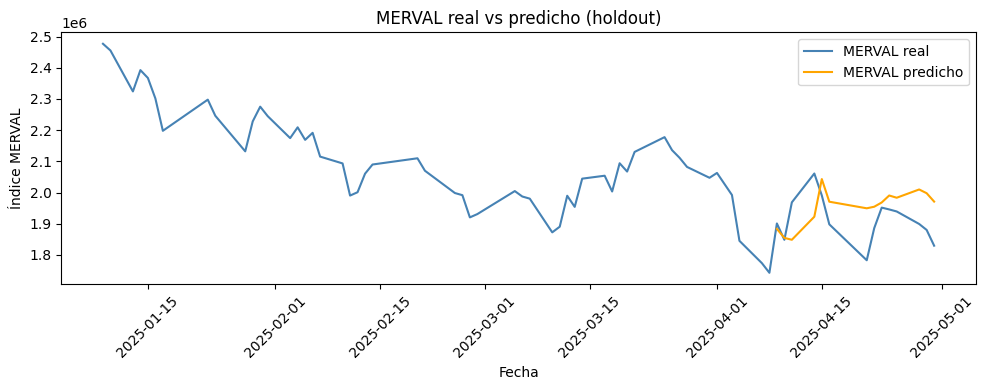

In [192]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


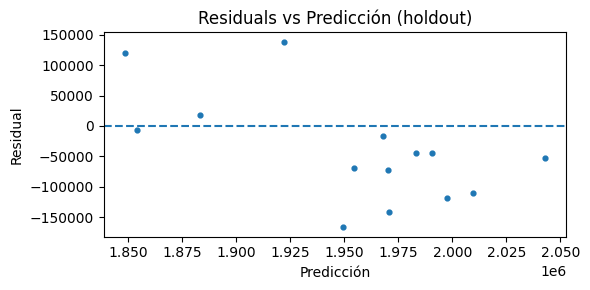

In [193]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


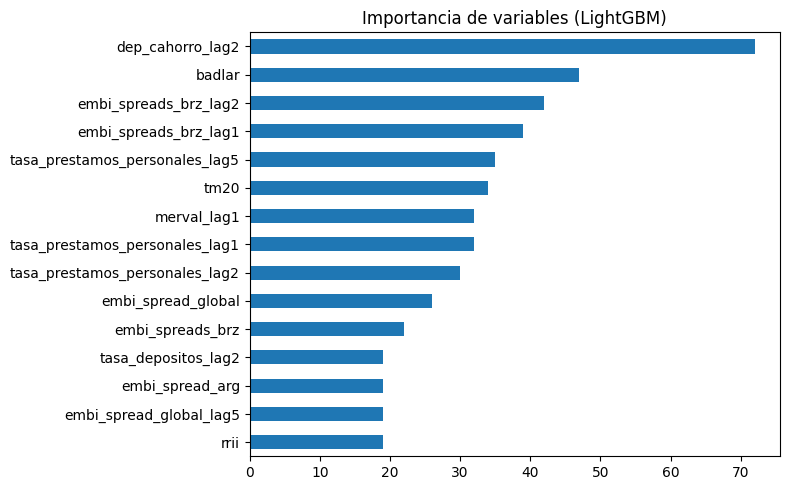

In [194]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
